<a href="https://colab.research.google.com/github/ingridcos/Programaria/blob/main/regressao_linear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#MÓDULO 7 - APRENDIZADO DE MÁQUINA

#Aula 1

In [605]:
import pandas as pd

In [606]:
dados = pd.read_excel('/content/drive/MyDrive/Programaria/Módulo 7/regressao_linear.xlsx')

In [607]:
dados = dados.copy()  # garante que é uma cópia "oficial"

In [608]:
dados.columns

Index(['ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA', 'PCD',
       'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'NOVO_NIVEL', 'NIVEL_Júnior', 'NIVEL_Pleno', 'NIVEL_Sênior',
       'GEARACAO', 'Quanto tempo de experiência na área de dados você tem?',
       'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?',
       'Você está satisfeito na sua 

Filtrando a situação atual de trabalho

In [609]:
dados['QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?'].value_counts()

,count
QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?,
Empregado (CLT),2762
Empreendedor ou Empregado (CNPJ),410
"Desempregado, buscando recolocação",350
Estagiário,188
Servidor Público,156
Trabalho na área Acadêmica/Pesquisador,86
Somente Estudante (graduação),82
Vivo no Brasil e trabalho remoto para empresa de fora do Brasil,69
Vivo fora do Brasil e trabalho para empresa de fora do Brasil,46


In [610]:
dados['QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?'].value_counts()['Empregado (CLT)']

np.int64(2762)

Organizando colunas de cor/raça/etnia

In [611]:
dados['COR/RACA/ETNIA'].value_counts ()

,count
COR/RACA/ETNIA,
Branca,2744
Parda,1054
Preta,291
Amarela,128
Prefiro não informar,26
Outra,17
Indígena,11


In [612]:
lista_retirar = ['Prefiro não informar', 'Outra', 'Indígena']

In [613]:
dados = dados[~dados['COR/RACA/ETNIA'].isin(lista_retirar)]

In [614]:
dados['NAO_BRANCA'] = dados['COR/RACA/ETNIA'].apply(lambda x: 1 if x!='Branca' else 0)

In [615]:
dados['NAO_BRANCA'].value_counts()

,count
NAO_BRANCA,
0,2744
1,1473


In [616]:
dados['COR/RACA/ETNIA'].value_counts()

,count
COR/RACA/ETNIA,
Branca,2744
Parda,1054
Preta,291
Amarela,128


Coluna tempo de experiência

In [617]:
dados['QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?'].value_counts()

,count
QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,
de 1 a 2 anos,965
de 3 a 4 anos,707
Menos de 1 ano,589
de 4 a 6 anos,515
Mais de 10 anos,395
de 7 a 10 anos,289
Não tenho experiência na área de dados,186


In [618]:
dados['QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?'].str.extract(r'(\d+)')

,0
0,1
1,3
2,3
3,4
4,NaN
...,...
4266,3
4267,1
4268,4
4269,1


In [619]:
dados['TEMPO_EXPERIENCIA'] = dados['QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?'].str.extract(r'(\d+)')

In [620]:
dados['TEMPO_EXPERIENCIA'].value_counts()

,count
TEMPO_EXPERIENCIA,
1,1554
3,707
4,515
10,395
7,289


Coluna número de funcionários

In [621]:
dados['NUMERO DE FUNCIONARIOS'].value_counts()

,count
NUMERO DE FUNCIONARIOS,
Acima de 3.000,1506
de 101 a 500,695
de 1.001 a 3.000,446
de 501 a 1.000,340
de 11 a 50,247
de 51 a 100,234
de 1 a 5,115
de 6 a 10,63


In [622]:
dados['NUMERO DE FUNCIONARIOS'].str.replace('.', '')


,NUMERO DE FUNCIONARIOS
0,Acima de 3000
1,Acima de 3000
2,Acima de 3000
3,Acima de 3000
4,de 101 a 500
...,...
4266,Acima de 3000
4267,de 51 a 100
4268,de 101 a 500
4269,de 1001 a 3000


In [623]:
dados['NUMERO DE FUNCIONARIOS'] = dados['NUMERO DE FUNCIONARIOS'].str.replace('.', '')

In [624]:
dados['NUMERO DE FUNCIONARIOS'].value_counts()

,count
NUMERO DE FUNCIONARIOS,
Acima de 3000,1506
de 101 a 500,695
de 1001 a 3000,446
de 501 a 1000,340
de 11 a 50,247
de 51 a 100,234
de 1 a 5,115
de 6 a 10,63


In [625]:
dados['NUMERO DE FUNCIONARIOS'].str.extract(r'(\d+)')

,0
0,3000
1,3000
2,3000
3,3000
4,101
...,...
4266,3000
4267,51
4268,101
4269,1001


In [626]:
dados['NUMERO DE FUNCIONARIOS'] = dados['NUMERO DE FUNCIONARIOS'].str.extract(r'(\d+)')

In [627]:
dados['NUMERO DE FUNCIONARIOS'].value_counts()

,count
NUMERO DE FUNCIONARIOS,
3000,1506
101,695
1001,446
501,340
11,247
51,234
1,115
6,63


In [628]:
dados['NUMERO DE FUNCIONARIOS'].value_counts(dropna=False)

,count
NUMERO DE FUNCIONARIOS,
3000,1506
101,695
NaN,571
1001,446
501,340
11,247
51,234
1,115
6,63


In [629]:
dados['TEMPO_EXPERIENCIA'].value_counts(dropna=False)

,count
TEMPO_EXPERIENCIA,
1,1554
NaN,757
3,707
4,515
10,395
7,289


In [630]:
dados['TEMPO_EXPERIENCIA'] = dados['TEMPO_EXPERIENCIA'].fillna(0)

In [631]:
dados['TEMPO_EXPERIENCIA'].value_counts(dropna=False)

,count
TEMPO_EXPERIENCIA,
1,1554
0,757
3,707
4,515
10,395
7,289


#Aula 2

In [632]:
dados.columns

Index(['ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA', 'PCD',
       'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'NOVO_NIVEL', 'NIVEL_Júnior', 'NIVEL_Pleno', 'NIVEL_Sênior',
       'GEARACAO', 'Quanto tempo de experiência na área de dados você tem?',
       'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?',
       'Você está satisfeito na sua 

In [633]:
dados['Qual o principal motivo da sua insatisfação com a empresa atual?'].value_counts()

,count
Qual o principal motivo da sua insatisfação com a empresa atual?,
Gostaria de trabalhar em em outra área de atuação,110
Salário atual não corresponde ao mercado,76
Falta de oportunidade de crescimento no emprego atual,65
Falta de maturidade analítica na empresa,63
"Falta de oportunidade de crescimento no emprego atual, Salário atual não corresponde ao mercado, Falta de maturidade analítica na empresa",29
...,...
Dificuldade de Equilibrio Vida Pessoal e Profissional,1
Falta de organização nos processos internos,1
"Gostaria de receber mais benefícios, O clima de trabalho/ambiente não é bom, Falta de oportunidade de crescimento no emprego atual",1


 Criar nossa coluna insatisfação

In [634]:
dados['INSATISFACAO'] = 0

In [635]:
dados.loc[dados['Qual o principal motivo da sua insatisfação com a empresa atual?'].notnull(), 'Qual o principal motivo da sua insatisfação com a empresa atual?'].apply(lambda x: 1 if 'Salario' in x else 0)

,Qual o principal motivo da sua insatisfação com a empresa atual?
1,0
2,0
4,0
5,0
7,0
...,...
4238,0
4240,0
4264,0
4265,0


Atribua a coluna INSATISFACAO

In [636]:
dados.loc[dados['Qual o principal motivo da sua insatisfação com a empresa atual?'].notnull(), 'INSATISFACAO'] = dados.loc[dados['Qual o principal motivo da sua insatisfação com a empresa atual?'].notnull(), 'Qual o principal motivo da sua insatisfação com a empresa atual?'].apply(lambda x: 1 if 'Salário' in x else 0)

In [637]:
dados['INSATISFACAO'].value_counts()

,count
INSATISFACAO,
0,3848
1,369


Coluna de nível de ensino

In [638]:
dados['NIVEL DE ENSINO'].value_counts()

,count
NIVEL DE ENSINO,
Graduação/Bacharelado,1486
Pós-graduação,1297
Estudante de Graduação,609
Mestrado,515
Doutorado ou Phd,190
Não tenho graduação formal,109
Prefiro não informar,11


In [639]:
dados['NIVEL DE ENSINO'].apply(lambda x: 0 if x == 'Não tenho graduação formal' else
                                                            1 if x == 'Estudante de Graduação' else
                                                            2 if x == 'Graduação/Bacharelado' else
                                                            3 if x == 'Pós-graduação' else
                                                            4 if x == 'Mestrado' else
                                                            5 if x == 'Doutorado ou Phd' else -1)

,NIVEL DE ENSINO
0,3
1,2
2,3
3,5
4,3
...,...
4266,2
4267,4
4268,4
4269,0


In [640]:
dados['NIVEL DE ENSINO'] = dados['NIVEL DE ENSINO'].apply(lambda x: 0 if x == 'Não tenho graduação formal' else
                                                            1 if x == 'Estudante de Graduação' else
                                                            2 if x == 'Graduação/Bacharelado' else
                                                            3 if x == 'Pós-graduação' else
                                                            4 if x == 'Mestrado' else
                                                            5 if x == 'Doutorado ou Phd' else -1)

In [641]:
dados['NIVEL DE ENSINO'].value_counts()

,count
NIVEL DE ENSINO,
2,1486
3,1297
1,609
4,515
5,190
0,109
-1,11


#Aula 3

Seleção das colunas que utilizaremos

In [642]:
dados[['IDADE', 'GENERO', 'NAO_BRANCA', 'TEMPO_EXPERIENCIA', 'INSATISFACAO', 'SETOR', 'REGIAO ONDE MORA', 'NIVEL DE ENSINO', 'NUMERO DE FUNCIONARIOS', 'SALARIO', 'NOVO_NIVEL']]

,IDADE,GENERO,NAO_BRANCA,TEMPO_EXPERIENCIA,INSATISFACAO,SETOR,REGIAO ONDE MORA,NIVEL DE ENSINO,NUMERO DE FUNCIONARIOS,SALARIO,NOVO_NIVEL
0,3.900000e+01,Masculino,1,1,0,Setor Público,Centro-oeste,3,3000,11194.0,Júnior
1,3.200000e+01,Masculino,1,3,0,Outra Opção,Norte,2,3000,4695.0,Pessoa Gestora
2,5.300000e+01,Masculino,0,3,0,Finanças ou Bancos,Centro-oeste,3,3000,14202.0,Pleno
3,2.700000e+01,Masculino,0,4,0,Setor Automotivo,Sudeste,5,3000,15463.0,Sênior
4,4.600000e+01,Feminino,0,0,0,Setor Público,Norte,3,101,7733.0,Pleno
...,...,...,...,...,...,...,...,...,...,...,...
4266,2.600000e+01,Masculino,0,3,0,Tecnologia/Fábrica de Software,Sudeste,2,3000,4329.0,Pleno
4267,3.000000e+01,Feminino,0,1,0,Área de Consultoria,Sudeste,4,51,3758.0,Pleno
4268,2.900000e+01,Masculino,0,4,0,Setor Imobiliário/ Construção Civil,Sudeste,4,101,19607.0,Pessoa Gestora
4269,2.020548e+16,Masculino,0,1,0,Indústria,Sudeste,0,1001,989.0,Júnior


In [643]:
dados = dados[['IDADE', 'GENERO', 'NAO_BRANCA', 'TEMPO_EXPERIENCIA', 'INSATISFACAO', 'SETOR', 'REGIAO ONDE MORA', 'NIVEL DE ENSINO', 'NUMERO DE FUNCIONARIOS', 'SALARIO', 'NOVO_NIVEL']]

In [644]:
dados.columns

Index(['IDADE', 'GENERO', 'NAO_BRANCA', 'TEMPO_EXPERIENCIA', 'INSATISFACAO',
       'SETOR', 'REGIAO ONDE MORA', 'NIVEL DE ENSINO',
       'NUMERO DE FUNCIONARIOS', 'SALARIO', 'NOVO_NIVEL'],
      dtype='object')

In [645]:
pd.get_dummies(dados, columns=['GENERO', 'SETOR', 'NOVO_NIVEL', 'REGIAO ONDE MORA'], drop_first=True)

,IDADE,NAO_BRANCA,TEMPO_EXPERIENCIA,INSATISFACAO,NIVEL DE ENSINO,NUMERO DE FUNCIONARIOS,SALARIO,GENERO_Masculino,GENERO_Prefiro não informar,SETOR_Educação,...,SETOR_Varejo,SETOR_Área da Saúde,SETOR_Área de Consultoria,NOVO_NIVEL_Pessoa Gestora,NOVO_NIVEL_Pleno,NOVO_NIVEL_Sênior,REGIAO ONDE MORA_Nordeste,REGIAO ONDE MORA_Norte,REGIAO ONDE MORA_Sudeste,REGIAO ONDE MORA_Sul
0,3.900000e+01,1,1,0,3,3000,11194.0,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,3.200000e+01,1,3,0,2,3000,4695.0,True,False,False,...,False,False,False,True,False,False,False,True,False,False
2,5.300000e+01,0,3,0,3,3000,14202.0,True,False,False,...,False,False,False,False,True,False,False,False,False,False
3,2.700000e+01,0,4,0,5,3000,15463.0,True,False,False,...,False,False,False,False,False,True,False,False,True,False
4,4.600000e+01,0,0,0,3,101,7733.0,False,False,False,...,False,False,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4266,2.600000e+01,0,3,0,2,3000,4329.0,True,False,False,...,False,False,False,False,True,False,False,False,True,False
4267,3.000000e+01,0,1,0,4,51,3758.0,False,False,False,...,False,False,True,False,True,False,False,False,True,False
4268,2.900000e+01,0,4,0,4,101,19607.0,True,False,False,...,False,False,False,True,False,False,False,False,True,False
4269,2.020548e+16,0,1,0,0,1001,989.0,True,False,False,...,False,False,False,False,False,False,False,False,True,False


In [646]:
dados = pd.get_dummies(dados, columns=['GENERO', 'SETOR', 'NOVO_NIVEL', 'REGIAO ONDE MORA'], drop_first=True)

In [647]:
X = dados.drop('SALARIO', axis=1)
y = dados['SALARIO']

In [648]:
from sklearn.model_selection import train_test_split

In [649]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [650]:
from sklearn.preprocessing import StandardScaler

In [651]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

#Aula 4

In [657]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression

In [658]:
# cria o imputer (aqui usando a média para preencher NaN)
imputer = SimpleImputer(strategy='mean')

In [659]:
# ajusta e transforma os dados de treino
X_train_imputed = imputer.fit_transform(X_train_scaled)

In [660]:
# aplica a mesma transformação nos dados de teste
X_test_imputed = imputer.transform(X_test_scaled)

In [661]:
# Criamos o objeto:
model = LinearRegression()

In [663]:
# Enviamos os parâmetros de treino na função fit
model.fit(X_train_imputed, y_train)

LinearRegression()

In [664]:
y_pred = model.predict(X_test_imputed)

In [669]:
# Se ainda não tiver feito no treino, o ideal é ajustar no treino:
X_train_scaled = imputer.fit_transform(X_train_scaled)
X_test_scaled = imputer.transform(X_test_scaled)

In [670]:
# Fazemos as predições do nosso conjunto de teste utilizando a função predict:
model.predict(X_test_scaled)

array([ 1.45044800e+04,  1.53830922e+04,  5.98116138e+03,  2.68361219e+03,
        1.61896473e+04,  3.27608120e+03,  6.46695936e+03,  1.93865139e+04,
        7.04117680e+03,  3.56266579e+03,  1.01753588e+04,  8.91038651e+03,
        2.92162834e+03,  1.14801849e+04,  2.56311713e+03,  1.29041952e+04,
        1.02795569e+04,  1.05068267e+04,  4.42679059e+03,  6.50061008e+03,
        5.53383629e+03,  6.52051856e+03,  1.14147991e+04,  1.80193171e+03,
        2.69838283e+03,  7.35254483e+03,  7.23908288e+03,  1.17750981e+04,
        7.90864320e+03,  8.24813369e+03,  9.67916853e+03,  9.31711490e+03,
        1.39704887e+04,  1.16262567e+04,  6.11507150e+03,  1.82325546e+04,
        3.32412432e+03,  1.53891678e+03,  3.96283639e+03,  7.07661694e+03,
        1.11212595e+04,  8.08927934e+03,  1.15397611e+04,  1.39031477e+04,
        6.22990881e+03,  1.09533752e+04,  6.85689034e+03,  7.60959756e+03,
        5.74088945e+03,  7.33363607e+03,  1.33381007e+04,  4.78963064e+03,
        6.16147640e+03,  

In [671]:
# Vamos atribuir o resultado para uma variável que vamos chamar de y_pred:
y_pred = model.predict(X_test_scaled)

In [673]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1) Imputador para substituir NaN pela média das colunas
imputer = SimpleImputer(strategy='mean')

# Ajusta NO TREINO e transforma treino e teste
X_train_imp = imputer.fit_transform(X_train_scaled)
X_test_imp  = imputer.transform(X_test_scaled)

# 2) Treina o modelo com dados sem NaN
model = LinearRegression()
model.fit(X_train_imp, y_train)

# 3) Predições no teste
y_pred = model.predict(X_test_imp)

# 4) Métricas
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("MSE:", mse)
print("R²:", r2)
print("MAE:", mae)

MSE: 33443598.544817775
R²: 0.43198502619240453
MAE: 3651.4595959698836


In [675]:
from sklearn.metrics import mean_squared_error, r2_score

In [677]:
# Remove todas as linhas que tenham pelo menos um NaN
df_sem_nan = dados.dropna()

# Depois define X e y a partir de df_sem_nan normalmente

In [678]:
# Vamos calcular o erro quadrático médio, o MSE.
mse = mean_squared_error(y_test, y_pred)

In [681]:
mse

33443598.544817775

In [679]:
# Podemos adicionar mais uma métrica (MAE) na importação e executar em seguida:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [680]:
# Agora sim, fazemos o cálculo do MAE:
mae = mean_absolute_error(y_test, y_pred)

In [682]:
mae

3651.4595959698836

In [683]:
r2 = r2_score(y_test, y_pred)
print("R²:", r2)

R²: 0.43198502619240453


#Aula 5

In [684]:
import matplotlib.pyplot as plt

Esse código plota os valores reais vs. preditos e desenha a linha vermelha de referência


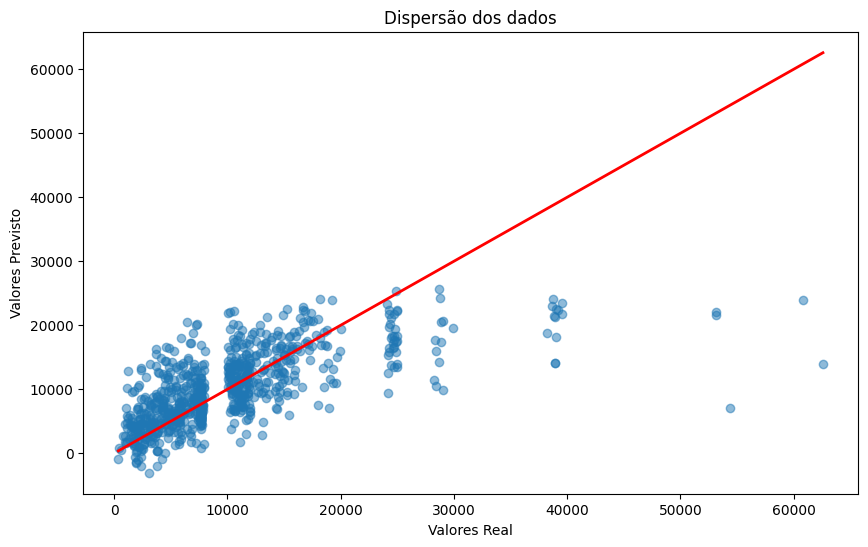

In [685]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Valores Real')
plt.ylabel('Valores Previsto')
plt.title('Dispersão dos dados')
plt.plot([min(y_test), max(y_test)],
         [min(y_test), max(y_test)],
         color='red', linewidth=2)
plt.show()

In [686]:
# Vamos pegar os nomes das colunas de atributos e atribuir a uma variável
nomes_atributos = X_train.columns

In [690]:
nomes_atributos

Index(['IDADE', 'NAO_BRANCA', 'TEMPO_EXPERIENCIA', 'INSATISFACAO',
       'NIVEL DE ENSINO', 'NUMERO DE FUNCIONARIOS', 'GENERO_Masculino',
       'GENERO_Prefiro não informar', 'SETOR_Educação',
       'SETOR_Entretenimento ou Esportes', 'SETOR_Filantropia/ONG's',
       'SETOR_Finanças ou Bancos', 'SETOR_Indústria',
       'SETOR_Internet/Ecommerce', 'SETOR_Marketing', 'SETOR_Outra Opção',
       'SETOR_Seguros ou Previdência', 'SETOR_Setor Alimentício',
       'SETOR_Setor Automotivo', 'SETOR_Setor Farmaceutico',
       'SETOR_Setor Imobiliário/ Construção Civil', 'SETOR_Setor Público',
       'SETOR_Setor de Energia', 'SETOR_Tecnologia/Fábrica de Software',
       'SETOR_Telecomunicação', 'SETOR_Varejo', 'SETOR_Área da Saúde',
       'SETOR_Área de Consultoria', 'NOVO_NIVEL_Pessoa Gestora',
       'NOVO_NIVEL_Pleno', 'NOVO_NIVEL_Sênior', 'REGIAO ONDE MORA_Nordeste',
       'REGIAO ONDE MORA_Norte', 'REGIAO ONDE MORA_Sudeste',
       'REGIAO ONDE MORA_Sul'],
      dtype='object')

In [691]:
pd.DataFrame(model.coef_, columns=["coeficientes"], index=nomes_atributos)

,coeficientes
IDADE,-172.759909
NAO_BRANCA,-396.193568
TEMPO_EXPERIENCIA,2106.305091
INSATISFACAO,-833.621838
NIVEL DE ENSINO,976.627884
NUMERO DE FUNCIONARIOS,430.771587
GENERO_Masculino,595.269147
GENERO_Prefiro não informar,6.626951
SETOR_Educação,-978.102349
SETOR_Entretenimento ou Esportes,-41.081946


In [687]:
# Criamos um DataFrame com os coeficientes do modelo
coefs = pd.DataFrame(model.coef_, columns=["coeficientes"], index=nomes_atributos)

In [692]:
coefs.sort_values(by="coeficientes", ascending=False)

,coeficientes
NOVO_NIVEL_Pessoa Gestora,3691.699366
NOVO_NIVEL_Sênior,2310.635479
TEMPO_EXPERIENCIA,2106.305091
NOVO_NIVEL_Pleno,1097.322375
NIVEL DE ENSINO,976.627884
GENERO_Masculino,595.269147
NUMERO DE FUNCIONARIOS,430.771587
GENERO_Prefiro não informar,6.626951
SETOR_Entretenimento ou Esportes,-41.081946
SETOR_Internet/Ecommerce,-58.279990


In [693]:
# Ordenamos essa coluna de coeficientes para ver o que mais influencia
coefs = coefs.sort_values(by="coeficientes", ascending=False)

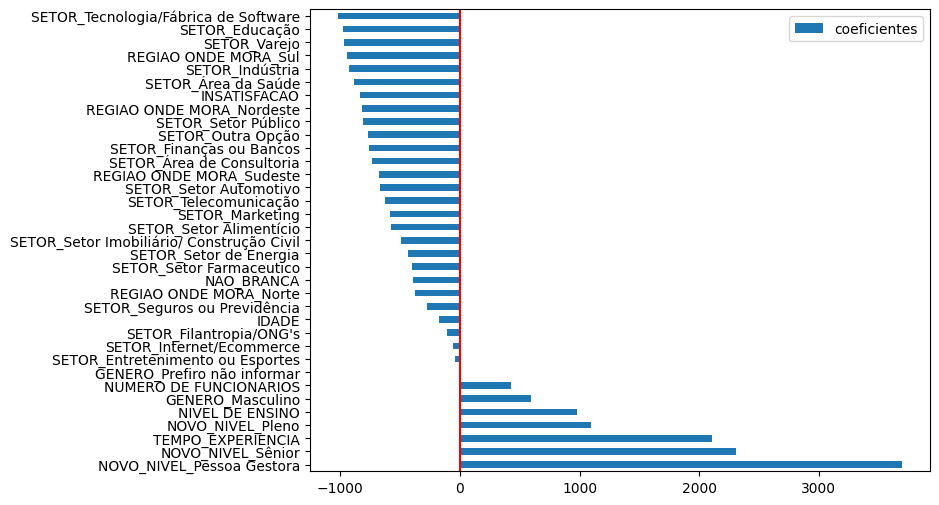

In [689]:
# Vamos plotar um gráfico de barras horizontal para visualizar melhor
# e adicionar uma linha vertical no ponto 0 como referência

coefs.plot.barh(figsize=(8, 6))
plt.axvline(x=0, color='red')
plt.show()